based on : https://www.geeksforgeeks.org/pspnet-pyramid-scene-parsing-network-for-image-segmentation/


how the test, validate and train are devided: https://www.v7labs.com/blog/train-validation-test-set

Train: 70%
Validate: 15%
Test: 15%

use GPU --> runtime --> change runtime type --> GPU

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import time
import os
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Convolution2D, BatchNormalization, ReLU, LeakyReLU, Add, Activation
from tensorflow.keras.layers import GlobalAveragePooling2D, AveragePooling2D, UpSampling2D


In [4]:
def load_image_mask_subset(path):
    file_name_patch = os.listdir(os.path.join(path, "patched"))
    file_name_mask = os.listdir(os.path.join(path, "segmentation"))

    num_samples = len(file_name_mask)

    image_list, mask_list = [], []
    for file_name in file_name_patch:
        image = cv2.imread(os.path.join(path, "patched", file_name))
        image = cv2.normalize(image, None, 0, 1, cv2.NORM_MINMAX, cv2.CV_32F)
        image = image[:, :, ::-1]
        # image = image.reshape(-1)
        image_list.append(image)
        del image

    for file_name in file_name_mask:
        mask = cv2.imread(os.path.join(path, "segmentation", file_name))
        mask = cv2.normalize(mask, None, 0, 1, cv2.NORM_MINMAX, cv2.CV_32F)
        mask_list.append(mask)
        del mask

    return image_list, mask_list, num_samples, file_name_patch

train_data_folder = "trainingdata/splitdata/train"
valid_data_folder = "trainingdata/splitdata/validate"
test_data_folder = "trainingdata/splitdata/test"
patchzero_folder = "patchzeroimages"

# train_data_folder = "/content/drive/MyDrive/trainingdata/splitdata/train"
# valid_data_folder = "/content/drive/MyDrive/trainingdata/splitdata/validate"
# test_data_folder = "/content/drive/MyDrive/trainingdata/splitdata/test"
# output_folder = "/content/drive/MyDrive/patchzeroimages"

train_images, train_masks, num_samples_train, file_name_train_patches = load_image_mask_subset(train_data_folder)
valid_images, valid_masks, num_samples_valid, file_name_valid_patches = load_image_mask_subset(valid_data_folder)
test_images, test_masks, num_samples_test,file_name_test_patches = load_image_mask_subset(test_data_folder)

imageshape = train_images[1].shape
imagesize = imageshape[0]

(577, 224, 224, 3)


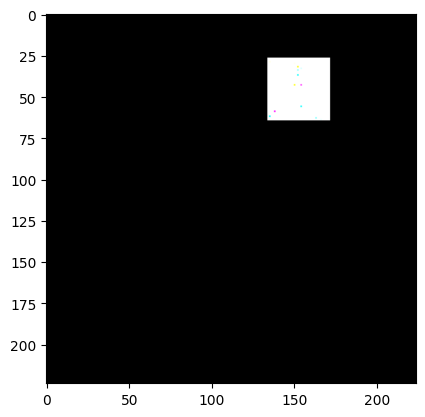

In [126]:
# Add noise to patch place of train_images

noise = np.random.rand(imagesize, imagesize, 3)
train_mask_noise = []
for mask in train_masks:
    mask_noise = mask*noise
    # mask_noise = mask_noise.reshape(-1)
    train_mask_noise.append(mask_noise)

plt.imshow(train_mask_noise[0].reshape(imagesize, imagesize, 3))
plt.show

print(np.shape(train_mask_noise))

In [127]:

def convolutional_block(input_tensor, filters, block_identifier):
    # Dilated convolution block
    block_name = 'block_' + str(block_identifier) + '_'
    filter1, filter2, filter3 = filters
    skip_connection = input_tensor

    # Block A
    input_tensor = Convolution2D(filters=filter1, kernel_size=(1, 1), dilation_rate=(1, 1),
                      padding='same', kernel_initializer='he_normal', name=block_name + 'a')(input_tensor)
    input_tensor = BatchNormalization(name=block_name + 'batch_norm_a')(input_tensor)
    input_tensor = LeakyReLU(alpha=0.2, name=block_name + 'leakyrelu_a')(input_tensor)

    # Block B
    input_tensor = Convolution2D(filters=filter2, kernel_size=(3, 3), dilation_rate=(2, 2),
                      padding='same', kernel_initializer='he_normal', name=block_name + 'b')(input_tensor)
    input_tensor = BatchNormalization(name=block_name + 'batch_norm_b')(input_tensor)
    input_tensor = LeakyReLU(alpha=0.2, name=block_name + 'leakyrelu_b')(input_tensor)

    # Block C
    input_tensor = Convolution2D(filters=filter3, kernel_size=(1, 1), dilation_rate=(1, 1),
                      padding='same', kernel_initializer='he_normal', name=block_name + 'c')(input_tensor)
    input_tensor = BatchNormalization(name=block_name + 'batch_norm_c')(input_tensor)

    # Skip convolutional block for residual
    skip_connection = Convolution2D(filters=filter3, kernel_size=(3, 3), padding='same', name=block_name + 'skip_conv')(skip_connection)
    skip_connection = BatchNormalization(name=block_name + 'batch_norm_skip_conv')(skip_connection)

    # Block C + Skip Convolution
    input_tensor = Add(name=block_name + 'add')([input_tensor, skip_connection])
    input_tensor = ReLU(name=block_name + 'relu')(input_tensor)
    return input_tensor


In [128]:
def base_convolutional_block(input_layer):
    # Base convolutional block to obtain input image feature maps

    # Base Block 1
    base_result = convolutional_block(input_layer, [int(imagesize/8), int(imagesize/8), int(imagesize/4)], '1')

    # Base Block 2
    base_result = convolutional_block(base_result, [int(imagesize/4), int(imagesize/4), int(imagesize/2)], '2')

    # Base Block 3
    base_result = convolutional_block(base_result, [int(imagesize/2), int(imagesize/2), imagesize], '3')

    return base_result

def pyramid_pooling_module(input_layer):
    # Pyramid pooling module
    base_result = base_convolutional_block(input_layer)

    # Red Pixel Pooling
    red_result = GlobalAveragePooling2D(name='red_pool')(base_result)
    red_result = tf.keras.layers.Reshape((1, 1, imagesize))(red_result)
    red_result = Convolution2D(filters=64, kernel_size=(1, 1), name='red_1_by_1')(red_result)
    red_result = UpSampling2D(size=imagesize, interpolation='bilinear', name='red_upsampling')(red_result)

    # Yellow Pixel Pooling
    yellow_result = AveragePooling2D(pool_size=(2, 2), name='yellow_pool')(base_result)
    yellow_result = Convolution2D(filters=64, kernel_size=(1, 1), name='yellow_1_by_1')(yellow_result)
    yellow_result = UpSampling2D(size=2, interpolation='bilinear', name='yellow_upsampling')(yellow_result)

    # Blue Pixel Pooling
    blue_result = AveragePooling2D(pool_size=(4, 4), name='blue_pool')(base_result)
    blue_result = Convolution2D(filters=64, kernel_size=(1, 1), name='blue_1_by_1')(blue_result)
    blue_result = UpSampling2D(size=4, interpolation='bilinear', name='blue_upsampling')(blue_result)

    # Green Pixel Pooling
    green_result = AveragePooling2D(pool_size=(8, 8), name='green_pool')(base_result)
    green_result = Convolution2D(filters=64, kernel_size=(1, 1), name='green_1_by_1')(green_result)
    green_result = UpSampling2D(size=8, interpolation='bilinear', name='green_upsampling')(green_result)

    # Final Pyramid Pooling
    return tf.keras.layers.concatenate([base_result, red_result, yellow_result, blue_result, green_result])


In [129]:
def pyramid_based_conv(input_layer):
    result = pyramid_pooling_module(input_layer)
    result = Convolution2D(filters=3, kernel_size=3, padding='same', name='last_conv_3_by_3')(result)
    result = BatchNormalization(name='last_conv_3_by_3_batch_norm')(result)
    result = Activation('sigmoid', name='last_conv_relu')(result)
    # result = tf.keras.layers.Flatten(name='last_conv_flatten')(result)
    return result

input_layer = tf.keras.Input(shape=np.squeeze(train_images[0]).shape, name='input')
output_layer = pyramid_based_conv(input_layer)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [130]:
model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)        │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_a (Conv2D)        │ (None, 224, 224, 28)   │            112 │ input[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_batch_norm_a      │ (None, 224, 224, 28)   │            112 │ block_1_a[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_leakyrelu_a       │ (None, 224, 224, 28)   │              0 │ block_1_batch_norm_a[… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_b (Conv2D)        │ (None, 224, 224, 28)   │          7,084 │ block_1_leakyrelu_a[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_batch_norm_b      │ (None, 224, 224, 28)   │            112 │ block_1_b[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_leakyrelu_b       │ (None, 224, 224, 28)   │              0 │ block_1_batch_norm_b[… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_c (Conv2D)        │ (None, 224, 224, 56)   │          1,624 │ block_1_leakyrelu_b[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_skip_conv         │ (None, 224, 224, 56)   │          1,568 │ input[0][0]            │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_batch_norm_c      │ (None, 224, 224, 56)   │            224 │ block_1_c[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_batch_norm_skip_… │ (None, 224, 224, 56)   │            224 │ block_1_skip_conv[0][… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_add (Add)         │ (None, 224, 224, 56)   │              0 │ block_1_batch_norm_c[… │
│                           │                        │                │ block_1_batch_norm_sk… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_relu (ReLU)       │ (None, 224, 224, 56)   │              0 │ block_1_add[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_2_a (Conv2D)        │ (None, 224, 224, 56)   │          3,192 │ block_1_relu[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_2_batch_norm_a      │ (None, 224, 224, 56)   │            224 │ block_2_a[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 557,075 (2.13 MB)

 Trainable params: 554,717 (2.12 MB)

 Non-trainable params: 2,358 (9.21 KB)

In [131]:
print(np.shape(train_mask_noise))
print(np.shape(train_images))


batch_size = 8

steps_per_epoch = num_samples_train // batch_size
validation_steps = num_samples_valid // batch_size

# Compile and train the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

history = model.fit(
    np.array(train_images, dtype='float16'),
    np.array(train_mask_noise, dtype='float16'),
    validation_data=(np.array(valid_images, dtype='float16'), np.array(valid_masks, dtype='float16')),
    epochs=20, # TO DO increase to 50
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    verbose=1,
    batch_size=batch_size
)

(577, 224, 224, 3)
(577, 224, 224, 3)
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 58s 567ms/step - loss: 617.1391 - val_loss: 1857.5428
Epoch 2/20
 1/72 ━━━━━━━━━━━━━━━━━━━━ 8:50 7s/step - loss: 615.8053

/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 615.8053 - val_loss: 1857.0527
Epoch 3/20


KeyboardInterrupt: 

In [34]:
# save model
model.save('modelimagenet.keras')


# model.save('/content/drive/MyDrive/trainingdata/modelimagenet.keras')


In [3]:
# load model
model = keras.models.load_model('modelimagenet.keras')

# model = keras.models.load_model('/content/drive/MyDrive/trainingdata/modelimagenet.keras')

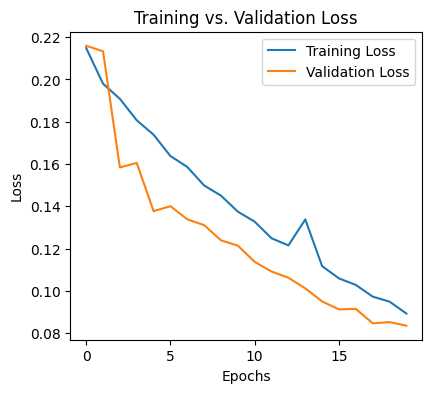

In [36]:
# Plot Loss vs. Accuracy
plt.figure(figsize=(10, 4))

# Plot Training vs. validation Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [94]:
# model evaluation based on comparison
def plot_imgs(img,mask,pred):
    mask = np.reshape(mask,(imagesize,imagesize,3))
    pred = np.reshape(pred,(imagesize,imagesize,3))
    fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,10))
    ax1.imshow(img)
    ax1.set_title('Original image')
    ax2.imshow(mask)
    ax2.set_title('Original mask')
    ax3.imshow(pred)
    ax3.set_title('Predicted mask')

pred_masks_valid = model.predict(np.array(valid_images,dtype='float16'))

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 642ms/step


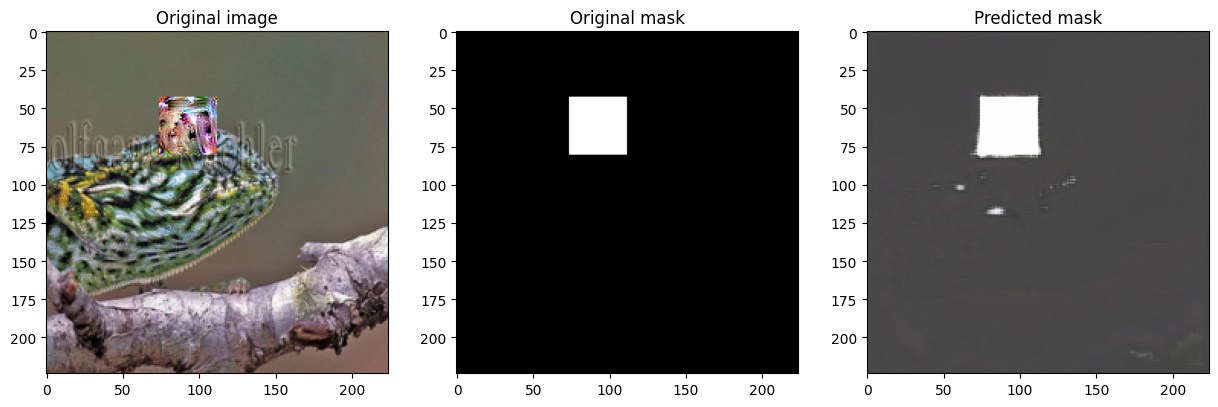

In [40]:
for i in range(1):
    x = np.random.randint(0,len(valid_images),size=1)[0]
    plot_imgs(valid_images[x],valid_masks[x],pred_masks_valid[x])

In [6]:
## model prediction for TEST

pred_masks_test = model.predict(np.array(test_images,dtype='float16'))


4/4 ━━━━━━━━━━━━━━━━━━━━ 61s 10s/step


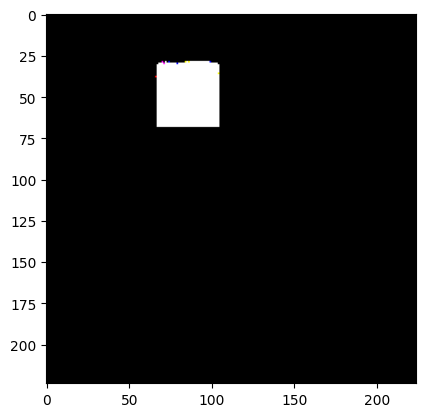

In [7]:
threshold_value = 0.7

pred_binary_masks = []

for mask in pred_masks_test:
  _, binary_image = cv2.threshold(mask, threshold_value, 1, cv2.THRESH_BINARY)
  pred_binary_masks.append(binary_image)


plt.imshow(pred_binary_masks[0], cmap="gray")
plt.show()


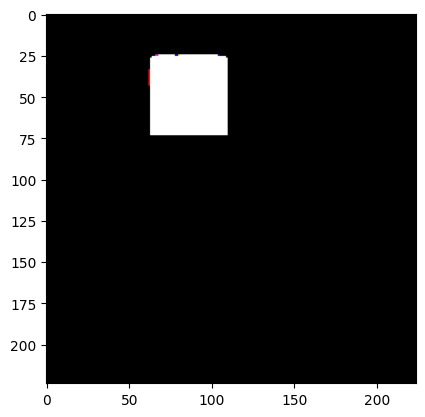

In [8]:
# post processing; dilate the image segmentation so the corners will also be implemented. (the box will become a little bit larger)
kernel = np.ones((10, 10), np.uint8)

dilated_masks = []
for mask in pred_binary_masks:
  dilated = cv2.dilate(mask, kernel, iterations=1)
  dilated_masks.append(dilated)

plt.imshow(dilated_masks[0], cmap="gray")
plt.show()


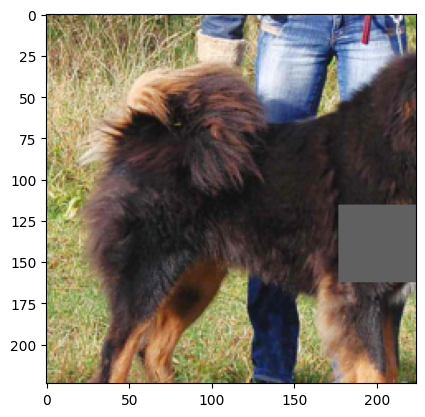

(123, 224, 224, 3)
1.0


In [9]:
## add the "gray" box to image
patchzero_images = []
# calculate average color without the masked section
for mask, image in zip(dilated_masks, test_images):
  masked_image = np.ma.masked_where(mask == 1, image)
  average_pixel_value = masked_image.mean()
  patchzero= image*(1-mask)+mask*average_pixel_value
  patchzero_images.append(patchzero)

plt.imshow(patchzero_images[45])
plt.show()


print(np.shape(patchzero_images))
print(np.max(patchzero_images))


In [11]:
# export patchzero_images

def interval_mapping(image, from_min, from_max, to_min, to_max):
    from_range = from_max - from_min
    to_range = to_max - to_min
    scaled = np.array((image - from_min) / float(from_range), dtype=float)
    return to_min + (scaled * to_range)


if not os.path.exists(output_folder):
    os.makedirs(output_folder)

for idx, patchzero in enumerate(patchzero_images):

    original_image_name = file_name_test_patches[idx]

    patchzero_image_uint8 = np.clip(patchzero * 255, 0, 255).astype(np.uint8) #de-normalize
    patchzero_image_uint8 = cv2.cvtColor(patchzero_image_uint8, cv2.COLOR_BGR2RGB)


    output_path = os.path.join(output_folder, original_image_name)
    cv2.imwrite(output_path, patchzero_image_uint8)

    print(f"Saved: {original_image_name} at {output_path}")

Saved: epoch_0_sample_476.png at /content/drive/MyDrive/patchzeroimages/epoch_0_sample_476.png
Saved: epoch_0_sample_456.png at /content/drive/MyDrive/patchzeroimages/epoch_0_sample_456.png
Saved: epoch_1_sample_2.png at /content/drive/MyDrive/patchzeroimages/epoch_1_sample_2.png
Saved: epoch_0_sample_584.png at /content/drive/MyDrive/patchzeroimages/epoch_0_sample_584.png
Saved: epoch_0_sample_296.png at /content/drive/MyDrive/patchzeroimages/epoch_0_sample_296.png
Saved: epoch_0_sample_648.png at /content/drive/MyDrive/patchzeroimages/epoch_0_sample_648.png
Saved: epoch_0_sample_430.png at /content/drive/MyDrive/patchzeroimages/epoch_0_sample_430.png
Saved: epoch_0_sample_319.png at /content/drive/MyDrive/patchzeroimages/epoch_0_sample_319.png
Saved: epoch_0_sample_179.png at /content/drive/MyDrive/patchzeroimages/epoch_0_sample_179.png
Saved: epoch_0_sample_276.png at /content/drive/MyDrive/patchzeroimages/epoch_0_sample_276.png
Saved: epoch_0_sample_444.png at /content/drive/MyDriv